Lienar Regression in Numpy

In [4]:
import numpy as np

In [3]:
import os

In [14]:
from pathlib import Path
import kagglehub


d:\practice_coding\uv-venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
os.makedirs('data_folder', exist_ok=True)

In [15]:
data_folder = Path('data_folder')
path = kagglehub.dataset_download("krishnaraj30/salary-prediction-data-simple-linear-regression", output_dir=str(data_folder), force_download=True)
print(path)


100%|██████████| 734/734 [00:00<?, ?B/s] 

Extracting files...
data_folder


In [ ]:
os.makedirs('my_folder', exist_ok=True)

In [ ]:
address = kagglehub.dataset_download("krishnaraj30/salary-prediction-data-simple-linear-regression", output_dir='my_folder', force_download=True)

In [16]:
import pandas as pd
dataset = pd.read_csv(data_folder/'Salary_Data.csv')
dataset

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [17]:
dataset['Salary']

0      39343.0
1      46205.0
2      37731.0
3      43525.0
4      39891.0
5      56642.0
6      60150.0
7      54445.0
8      64445.0
9      57189.0
10     63218.0
11     55794.0
12     56957.0
13     57081.0
14     61111.0
15     67938.0
16     66029.0
17     83088.0
18     81363.0
19     93940.0
20     91738.0
21     98273.0
22    101302.0
23    113812.0
24    109431.0
25    105582.0
26    116969.0
27    112635.0
28    122391.0
29    121872.0
Name: Salary, dtype: float64

In [18]:
dataset.shape

(30, 2)

In [19]:
dataset.dtypes

YearsExperience    float64
Salary             float64
dtype: object

In [20]:
dataset.head(10)

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [53]:
X = dataset['YearsExperience'].values
Y = dataset['Salary'].values

In [59]:
X[0]

np.float64(1.1)

In [22]:
type(X), type(Y)
len(X)

30

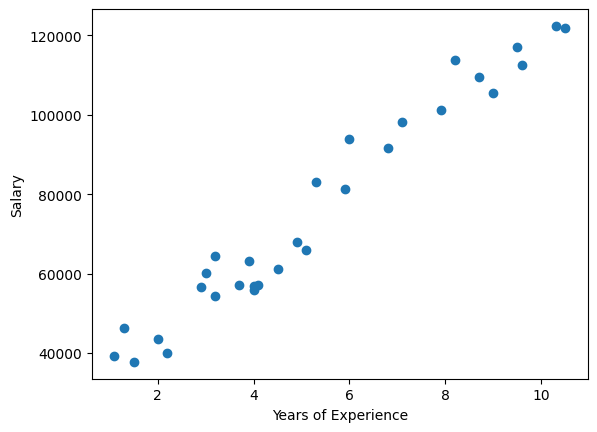

In [23]:
import matplotlib.pyplot as plt
plt.scatter(X,Y)
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

In [24]:
def cost_function(X, Y, w, b):
    total_points = len(X)
    cost_sum = 0
    
    for i in range(total_points):
        Y = w*X[i] + b
        cost = (X[i] - Y)**2
        cost_sum+=cost

    total_cost = (1/(2*total_points))*cost_sum
    return total_cost

In [25]:
def gradient_function (X, Y, w, b):
    dc_dw_sum = 0 
    dc_db_sum = 0
    for i in range(len(X)):
        dc_dw = X[i]*((w*X[i] + b)-Y[i])
        dc_dw_sum += dc_dw
        dc_db = ((w*X[i] + b)-Y[i])
        dc_db_sum += dc_db
    gradient_w = (1/len(X)) * dc_dw_sum
    gradient_b = (1/len(X)) * dc_db_sum
    return gradient_w, gradient_b

In [40]:
def gradient_descent(X, Y, alpha, iterations):
    w=0
    b=0

    for i in range(iterations):
        gradient_w, gradient_b = gradient_function(X, Y, w, b)
        w = w - alpha * gradient_w
        b = b - alpha * gradient_b
        print(f'MSE error: {cost_function(X, Y, w, b)}')
    return w, b
    

In [41]:
learning_rate = 0.01
iterations = 10000

final_w, final_b = gradient_descent(X, Y, alpha = learning_rate, iterations=iterations)

print(f'w: {float(final_w):.4f}, b:{float(final_b):.4f}')

MSE error: 429818674.79873776
MSE error: 1144899048.8175704
MSE error: 1773892233.9841185
MSE error: 2242110429.115782
MSE error: 2566246476.1005135
MSE error: 2782365113.1678805
MSE error: 2923447331.8356867
MSE error: 3014404862.6716266
MSE error: 3072605804.956436
MSE error: 3109674928.4203777
MSE error: 3133217682.5981145
MSE error: 3148143830.7440147
MSE error: 3157597427.768397
MSE error: 3163581862.2745233
MSE error: 3167369764.56625
MSE error: 3169768003.301903
MSE error: 3171287528.2827387
MSE error: 3172251652.248309
MSE error: 3172864858.7484846
MSE error: 3173256436.675107
MSE error: 3173508115.5428505
MSE error: 3173671553.7270355
MSE error: 3173779399.779626
MSE error: 3173852286.4655156
MSE error: 3173903252.172632
MSE error: 3173940535.630296
MSE error: 3173969342.272892
MSE error: 3173992960.5888634
MSE error: 3174013467.6349754
MSE error: 3174032174.9006553
MSE error: 3174049910.0775423
MSE error: 3174067195.125812
MSE error: 3174084358.80392
MSE error: 3174101607.781

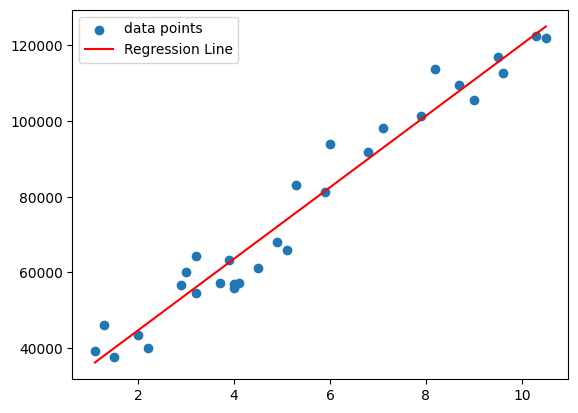

In [44]:
plt.scatter(X, Y, label='data points')

x_vals = np.linspace(min(X), max(X), 100)
y_vals = final_w * x_vals + final_b
plt.plot(x_vals, y_vals, color='red', label = "Regression Line")
plt.legend()

In [51]:
def cost_function(X, Y, w, b):
    total_points = len(X)
    cost_sum = 0
    
    for i in range(total_points):
        Y = w*X[i] + b
        cost = (X[i] - Y)**2
        cost_sum+=cost

    total_cost = (1/(2*total_points))*cost_sum
    return total_cost

def gradient_function (X, Y, w, b):
    dc_dw_sum = 0 
    dc_db_sum = 0
    for i in range(len(X)):
        dc_dw = X[i]*((w*X[i] + b)-Y[i])
        dc_dw_sum += dc_dw
        dc_db = ((w*X[i] + b)-Y[i])
        dc_db_sum += dc_db
    gradient_w = (1/len(X)) * dc_dw_sum
    gradient_b = (1/len(X)) * dc_db_sum
    return gradient_w, gradient_b

def gradient_descent(X, Y, iterations, lr):
    w = 0
    b = 0

    for i in range(iterations):
        gradient_w, gradient_b = gradient_function(X, Y, w, b)
        w = w - lr* gradient_w
        b = b - lr * gradient_b
        print(f'MSE Loss: {cost_function(X, Y, w, b)}')
    
    return w, b


total_iterations = 1000
lr = 0.01
w_final, b_final = gradient_descent(X, Y, total_iterations, lr)
print(w_final, b_final)

     

MSE Loss: 429818674.79873776
MSE Loss: 1144899048.8175704
MSE Loss: 1773892233.9841185
MSE Loss: 2242110429.115782
MSE Loss: 2566246476.1005135
MSE Loss: 2782365113.1678805
MSE Loss: 2923447331.8356867
MSE Loss: 3014404862.6716266
MSE Loss: 3072605804.956436
MSE Loss: 3109674928.4203777
MSE Loss: 3133217682.5981145
MSE Loss: 3148143830.7440147
MSE Loss: 3157597427.768397
MSE Loss: 3163581862.2745233
MSE Loss: 3167369764.56625
MSE Loss: 3169768003.301903
MSE Loss: 3171287528.2827387
MSE Loss: 3172251652.248309
MSE Loss: 3172864858.7484846
MSE Loss: 3173256436.675107
MSE Loss: 3173508115.5428505
MSE Loss: 3173671553.7270355
MSE Loss: 3173779399.779626
MSE Loss: 3173852286.4655156
MSE Loss: 3173903252.172632
MSE Loss: 3173940535.630296
MSE Loss: 3173969342.272892
MSE Loss: 3173992960.5888634
MSE Loss: 3174013467.6349754
MSE Loss: 3174032174.9006553
MSE Loss: 3174049910.0775423
MSE Loss: 3174067195.125812
MSE Loss: 3174084358.80392
MSE Loss: 3174101607.781968
MSE Loss: 3174119071.581842
MS

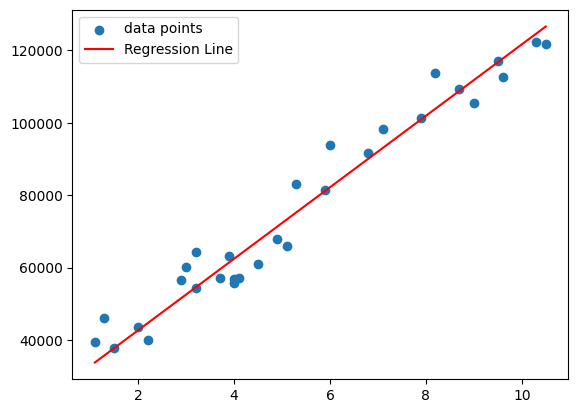

In [52]:
plt.scatter(X, Y, label='data points')

x_vals = np.linspace(min(X), max(X), 100)
y_vals = w_final * x_vals + b_final
plt.plot(x_vals, y_vals, color='red', label = "Regression Line")
plt.legend()